<a href="https://colab.research.google.com/github/vkekd25/Project_Electronic_Commerce/blob/main/E_commerce_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload() #내드라이브에 csv파일 불러오기

Saving shipping.csv to shipping (6).csv


# **제품 배송 시간에 맟춰 배송되나요? 전자상거래 고객의 요구에 부응하기위해**

In [2]:
#https://www.kaggle.com/datasets/prachi13/customer-analytics 해당 케글 사이트
import io
import pandas as pd
df = pd.read_csv(io.BytesIO(uploaded['shipping.csv'])) #data.csv불러오기
df.head(3)

df.rename(columns = {'Reached.on.Time_Y.N' : 'Reached_on_Time_YN'}, inplace = True) #편의를 위해 열이름 변경(데이터 전처리)!

In [3]:
!pip install pandas-profiling==3.1.0 #pandas-profiling 3.1.0 설치

In [4]:
from pandas_profiling import ProfileReport
profile = ProfileReport(df, minimal=True).to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Profile 내에서는 데이터에 대한 특이점은 없음

In [5]:
df.shape # 행 10999 열 12개

(10999, 12)

**콘텐츠**
모델 구축에 사용된 데이터 세트에는 12개의 변수에 대한 10999개의 관찰이 포함되었습니다.
데이터에는 다음 정보가 포함됩니다.

**ID**: 고객의 ID 번호입니다.   
**창고** 블록: 회사는 A,B,C,D,E와 같은 블록으로 구분된 큰 창고를 가지고 있습니다.   
**배송방법**: 회사는 선박, 항공, 육로 등 다양한 방법으로 제품을 배송합니다.   
**고객상담전화** : 배송조회 문의에서 걸려온 전화수입니다.   
**고객 평가**: 회사는 모든 고객으로부터 평가했습니다. 1이 가장 낮음(최악), 5가 가장 높음(최상)입니다.   
**제품 비용** : 제품 비용(미국 달러).   
**이전 구매**: 이전 구매 수.   
**제품 중요도**: 회사는 제품을 낮음, 중간, 높음과 같은 다양한 매개변수로 분류했습니다.   
**성별**: 남성과 여성.   
**할인 제공**: 특정 제품에 대해 제공되는 할인.   
**무게(g)**: 무게(g)입니다.   
**정시 도달**: 목표 변수로, 1은 제품이 정시에 도달하지 않았음을 나타내고 0은 정시에 도달했음을 나타냅니다.

In [6]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached_on_Time_YN   10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [8]:
df.isnull().sum() # 결측치 제로! Good!

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached_on_Time_YN     0
dtype: int64

In [9]:
df.duplicated(subset = ['ID']).sum() # 중복된 ID 없는거 확인!

0

#**상관계수에 대한 Heatmap**

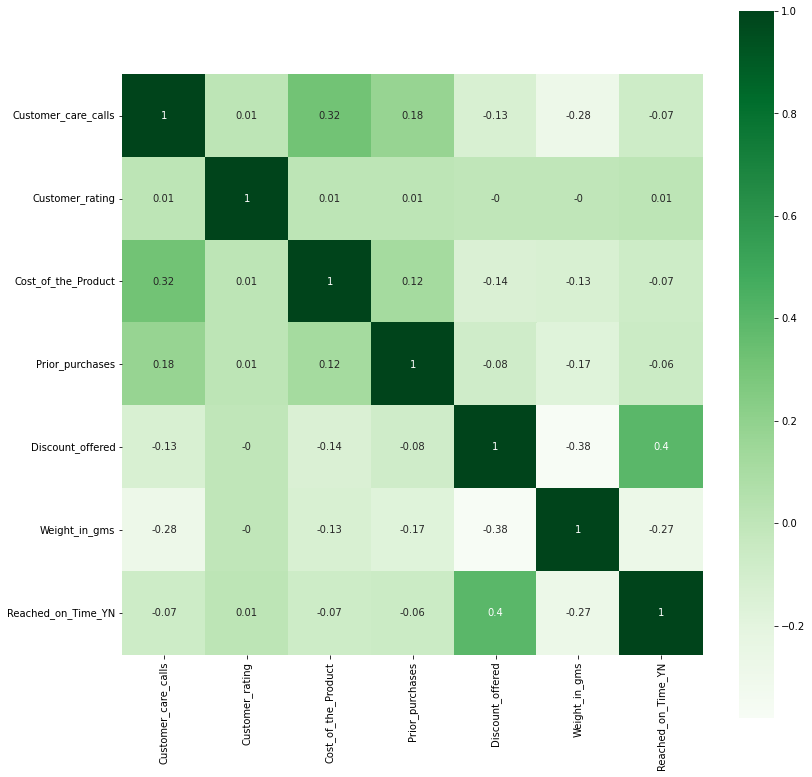

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline  
#matplot 그래프가 안나올시
plt.figure(figsize = (13, 13))
sns.heatmap(round(df[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product','Prior_purchases', 'Product_importance',
                'Discount_offered', 'Weight_in_gms','Reached_on_Time_YN']].corr(),2),square = True, cmap = 'Greens', annot = True);
plt.show()

상관계수로 봤을때   
Reached.on.Time_YN는 Weight_in_gm와 Discount_offered  
Customer_care_calls는 Cost_of_the_Product와 Weight_in_gms   
Discount_offered는 Weight_in_gms 밀접한 관계가 있을것으로 보입니다.

In [16]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [17]:
df.Warehouse_block.value_counts() #F=3666은 아마 E =  1833 결측된듯하다. 모든 블락의 count가 같기때문에 분석에 무의미하다.

F    3666
D    1834
A    1833
B    1833
C    1833
Name: Warehouse_block, dtype: int64

#**'Warehouse_block' E,F 결측치**

In [18]:
import pandas as pd
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
import numpy as np

df_EF = df[df['Warehouse_block'] == 'F']
scaler = StandardScaler()
Z = scaler.fit_transform(df_EF.iloc[:,[3, 4, 5, 6, 9, 10]])
column = df_EF.iloc[:,[3, 4, 5, 6, 9, 10]].columns
df1 = pd.DataFrame(Z, columns = column)
kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans.fit(df_EF.iloc[:,[3, 4, 5, 6, 9, 10]])
label_new = kmeans.labels_
df_EF1 = df_EF.copy()
df_EF1['Warehouse_block_new'] = label_new

warehouse_index = df[df['Warehouse_block'] == 'F'].index
df = df.drop(warehouse_index)

In [19]:
def toStr(x):
  x = str(x)
  if x == '0':
    return x.replace('0', 'E')
  if x == '1':
    return x.replace('1', 'F')

In [20]:
df_EF1['Warehouse_block_new'] = df_EF1.Warehouse_block_new.apply(toStr)
df_EF1 = df_EF1.drop('Warehouse_block', axis = 1)
df_EF1 = df_EF1[['ID', 'Warehouse_block_new','Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating',
       'Cost_of_the_Product', 'Prior_purchases', 'Product_importance',
       'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached_on_Time_YN']]

df_EF1 = df_EF1.rename(columns={'Warehouse_block_new':'Warehouse_block'})

df = pd.concat([df, df_EF1])
df = df.reset_index()
df = df.drop('index', axis = 1)

In [23]:
df['Warehouse_block'].value_counts()

E    2193
D    1834
A    1833
B    1833
C    1833
F    1473
Name: Warehouse_block, dtype: int64

#**각 Features(범위가 큰 수치형 제외)의 카테고리별 Count수**

In [ ]:
df.head(3)

In [ ]:
df.columns

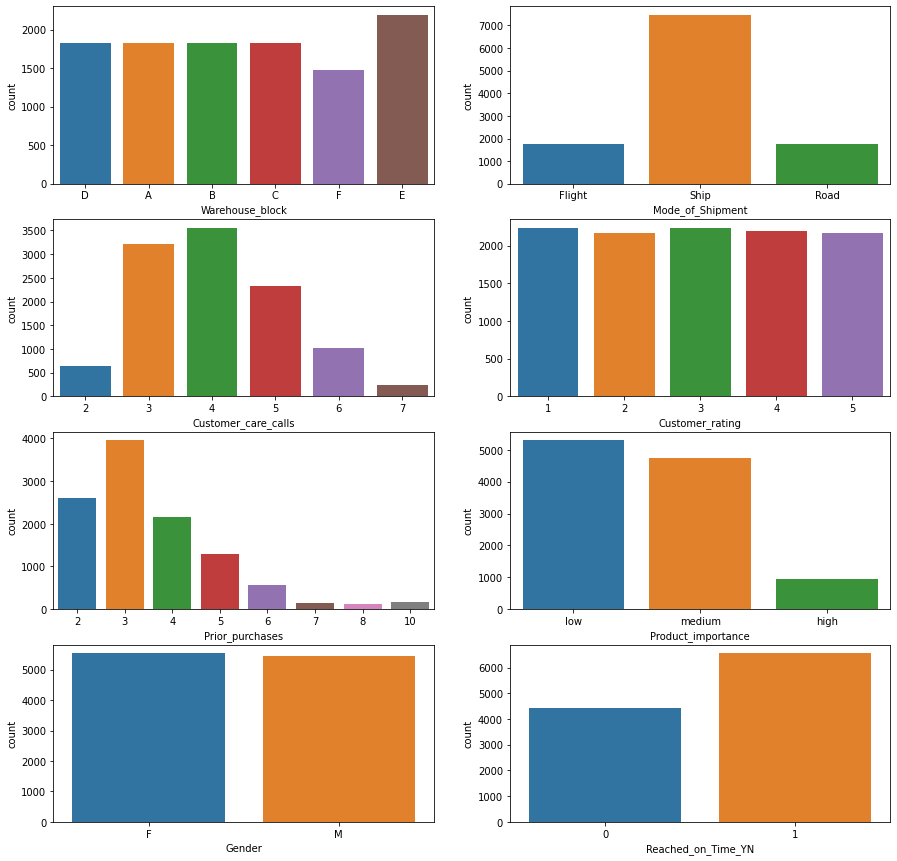

In [24]:
features = ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Prior_purchases',
       'Product_importance', 'Gender', 'Reached_on_Time_YN']
plt.figure(figsize = (15, 15))
k = 1

for i in range(len(features)):
  if k <= 8:
    ax = plt.subplot(4, 2, k)
    sns.countplot(x = features[i], data = df)
    k += 1
plt.show()

In [ ]:
df.Mode_of_Shipment.value_counts()

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Mode_of_Shipment.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [ ]:
df.Customer_care_calls.value_counts()

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Customer_care_calls.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [ ]:
df[df['Reached_on_Time_YN'] ==1]['Customer_care_calls'].value_counts()

In [ ]:
Carecall_Y = df[df['Reached_on_Time_YN'] ==1]['Customer_care_calls'].value_counts()
Carecall_N = df[df['Reached_on_Time_YN'] ==0]['Customer_care_calls'].value_counts()

In [ ]:
df_carecall = pd.DataFrame([Carecall_Y, Carecall_N])
df_carecall = df_carecall.reset_index()
df_carecall = df_carecall.drop(['index'], axis = 1)

In [ ]:
df_carecall.index = ['no arrived', 'arrived']
df_carecall

In [ ]:
df.Customer_rating.value_counts()

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Customer_rating.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [ ]:
df.Prior_purchases.value_counts()

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Prior_purchases.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [ ]:
df.Product_importance.value_counts()

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Product_importance.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [ ]:
df.Gender.value_counts()

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Gender.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [ ]:
df.Reached_on_Time_YN.value_counts()

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Reached_on_Time_YN.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [ ]:
df_shipment = df.groupby(['Mode_of_Shipment','Reached_on_Time_YN'])[['Reached_on_Time_YN']].count()
df_shipment.rename(columns = {'Reached_on_Time_YN' : 'Reached_on_Time_Count'}, inplace = True)
df_shipment = df_shipment.reset_index()

In [ ]:
Shipment_Y = df[df['Reached_on_Time_YN'] ==1]['Mode_of_Shipment'].value_counts()
Shipment_N = df[df['Reached_on_Time_YN'] ==0]['Mode_of_Shipment'].value_counts()

In [ ]:
df_shipment = pd.DataFrame([Shipment_Y, Shipment_N])
df_shipment = df_shipment.reset_index()
df_shipment = df_shipment.drop(['index'], axis = 1)

In [ ]:
df_shipment.index = ['no arrived', 'arrived']
df_shipment

In [ ]:
df.head(3)

In [ ]:
Shipment_YN = df[['Mode_of_Shipment', 'Reached_on_Time_YN']].astype('category')
Shipment_YN

In [ ]:
Discount_Y = df[df['Reached_on_Time_YN'] ==1]['Discount_offered'].value_counts()
Discount_N = df[df['Reached_on_Time_YN'] ==0]['Discount_offered'].value_counts()

In [ ]:
sns.boxplot(x = 'Reached_on_Time_YN', y = 'Discount_offered', data = df);

In [ ]:
sns.boxplot(x = 'Reached_on_Time_YN', y = 'Weight_in_gms', data = df);